<a href="https://colab.research.google.com/github/praveenbunker/data-science-project/blob/main/Car_Insurance_Claim_Prediction/Car_Insurance_Claim_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [16]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [17]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [18]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


## Dataset ka size

In [19]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 58592
Number of Columns: 44


In [20]:
# Columns dekho
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder', 'area_cluster', 'population_density', 'make', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder', 'transmission_type', 'gear_box', 'steering_type', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim']


## Dataset Information:
Isse pata chalega:

1. column names



2.data types

3.missing values


4.number of entries

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

Statical summary

In [22]:
df.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,3.137066,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,1.832641,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


## **Missing Values Check**

In [23]:
missing_values = df.isnull().sum()

print(missing_values)

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length      

In [24]:
# find missing values percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

policy_id                           0.0
policy_tenure                       0.0
age_of_car                          0.0
age_of_policyholder                 0.0
area_cluster                        0.0
population_density                  0.0
make                                0.0
segment                             0.0
model                               0.0
fuel_type                           0.0
max_torque                          0.0
max_power                           0.0
engine_type                         0.0
airbags                             0.0
is_esc                              0.0
is_adjustable_steering              0.0
is_tpms                             0.0
is_parking_sensors                  0.0
is_parking_camera                   0.0
rear_brakes_type                    0.0
displacement                        0.0
cylinder                            0.0
transmission_type                   0.0
gear_box                            0.0
steering_type                       0.0


## Duplicate Values

In [25]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### remove duplicate **values**

In [26]:
df = df.drop_duplicates()

print("Duplicates removed.")
print("New shape:", df.shape)

Duplicates removed.
New shape: (58592, 44)


### **Target Variable Identify karo**

In [27]:
df.columns

Index(['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder',
       'area_cluster', 'population_density', 'make', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim'],
      dtype='object')

In [29]:
print(df["is_claim"].value_counts())

is_claim
0    54844
1     3748
Name: count, dtype: int64


### **Claim Distribution Graph**

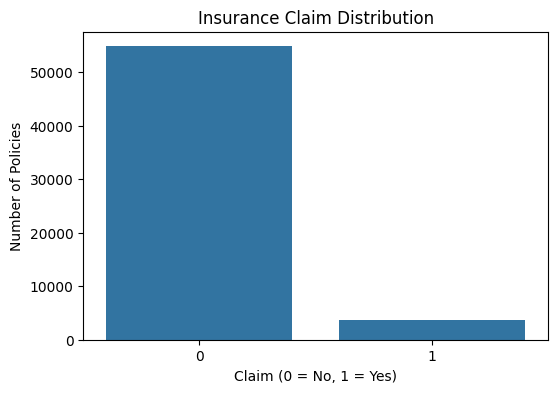

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x="is_claim", data=df)

plt.title("Insurance Claim Distribution")
plt.xlabel("Claim (0 = No, 1 = Yes)")
plt.ylabel("Number of Policies")

plt.show()

### **Claim Percentage**

In [31]:
claim_percentage = df["is_claim"].value_counts(normalize=True) * 100

print(claim_percentage)

is_claim
0    93.603222
1     6.396778
Name: proportion, dtype: float64


### **Numerical Columns**

In [32]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

Numerical Columns:
['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'airbags', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'ncap_rating', 'is_claim']


### ***Categorical Columns***

In [33]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['policy_id', 'area_cluster', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


### **Policy ID Check**


*   policy_id sirf identifier hai, prediction ke liye useful feature nahi hai.




In [34]:
print(df["policy_id"].head())

0    ID00001
1    ID00002
2    ID00003
3    ID00004
4    ID00005
Name: policy_id, dtype: object


## **Feature and Target Separation**

In [35]:
X = df.drop(["is_claim", "policy_id"], axis=1)

y = df["is_claim"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (58592, 42)
Target: (58592,)


## ***EDA - Claim vs Policy Tenure***

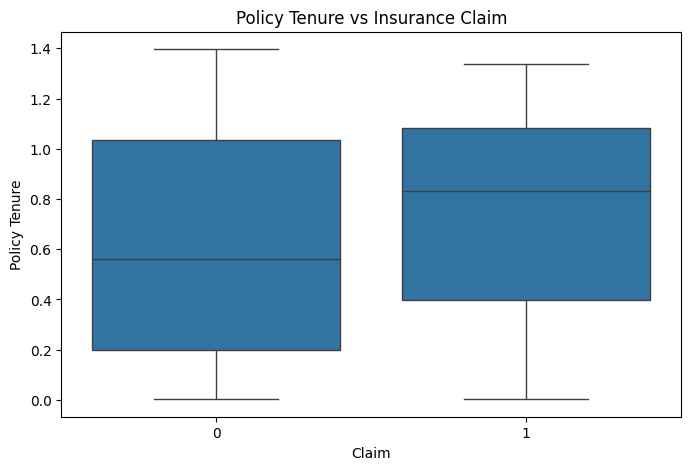

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x="is_claim", y="policy_tenure", data=df)

plt.title("Policy Tenure vs Insurance Claim")
plt.xlabel("Claim")
plt.ylabel("Policy Tenure")

plt.show()

## ***Claim vs Age of Car***

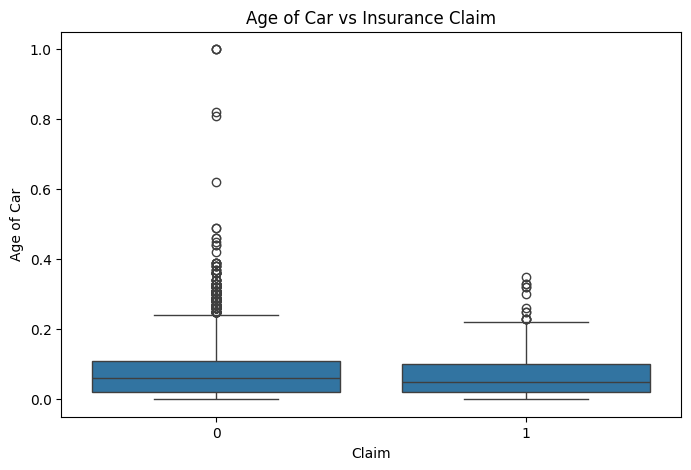

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x="is_claim", y="age_of_car", data=df)

plt.title("Age of Car vs Insurance Claim")
plt.xlabel("Claim")
plt.ylabel("Age of Car")

plt.show()

## ***Claim vs Age of Policyholder***

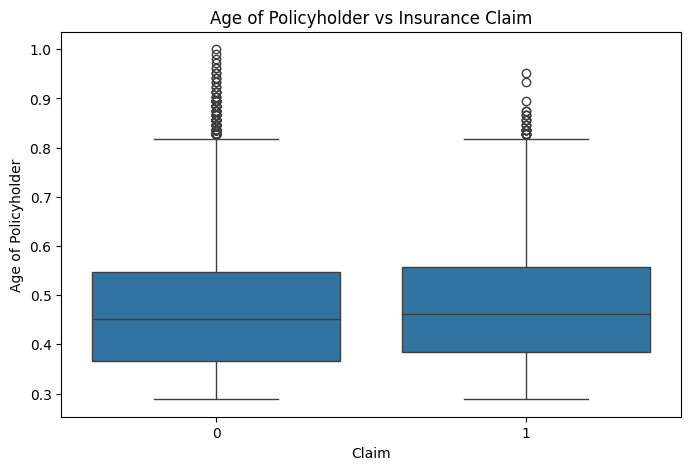

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(x="is_claim", y="age_of_policyholder", data=df)

plt.title("Age of Policyholder vs Insurance Claim")
plt.xlabel("Claim")
plt.ylabel("Age of Policyholder")

plt.show()

## ***Correlation Heatmap***

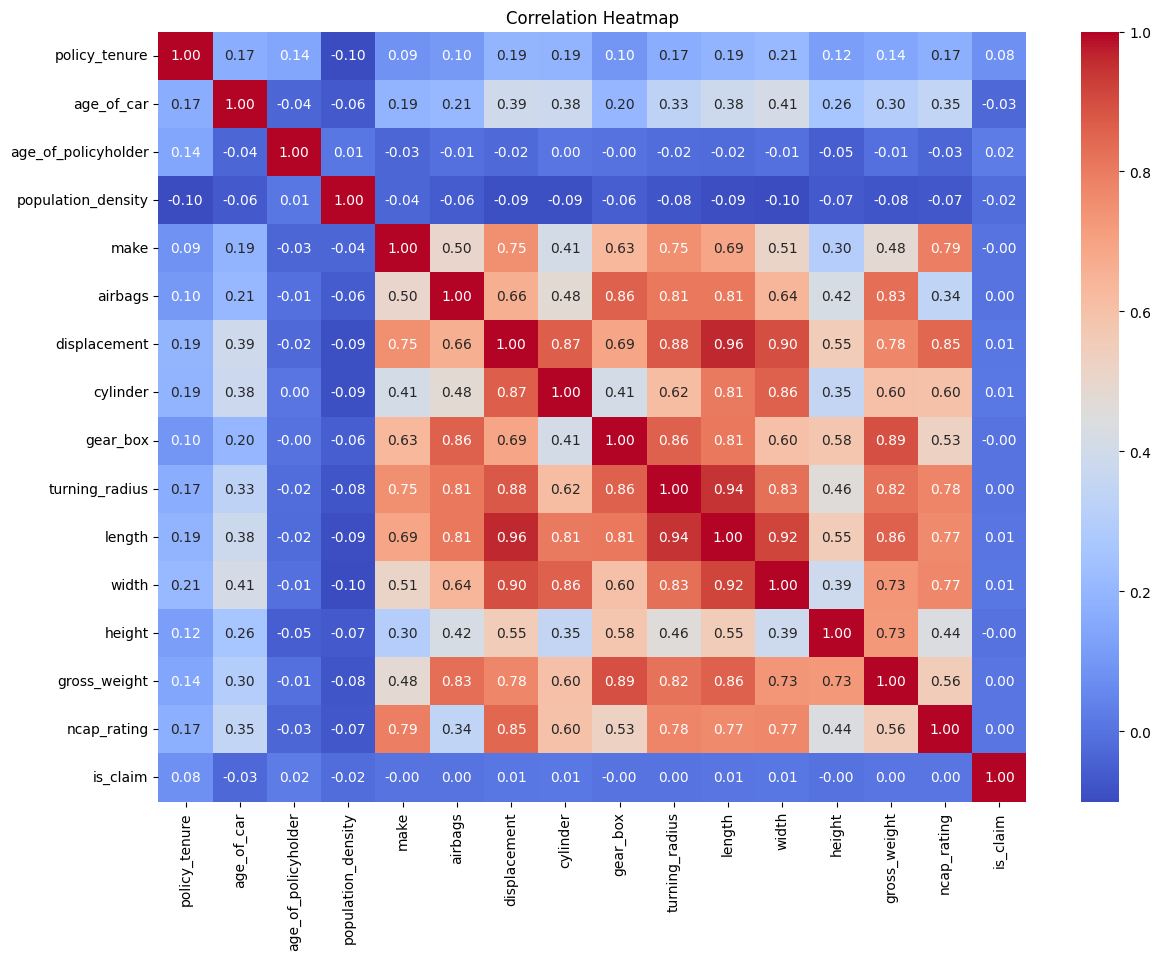

In [39]:
plt.figure(figsize=(14,10))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## ***Train-Test Split***

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (46873, 42)
Testing data: (11719, 42)


## ***Identify Numerical & Categorical Features***

In [41]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'airbags', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'ncap_rating']

Categorical Features:
['area_cluster', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


## ***Preprocessing Pipeline***



*   Yahan categorical columns ko One-Hot Encoding karenge
*   One-Hot Encoding kya karta hai?

Machine Learning model normally "Petrol" ya "Diesel" jaise words ko directly understand nahi karta.

Isliye One-Hot Encoding categories ko 0 aur 1 mein convert karta hai.



In [47]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


## **Logistic Regression**

In [48]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


## **Logistic Regression Evaluation**

In [49]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression
-------------------
Accuracy : 0.5694171857667036
Precision: 0.08014073494917905
Recall   : 0.5466666666666666
F1 Score : 0.13978861234231163


## **Decision Tree**

In [50]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


## **Decision Tree Evaluation**

In [51]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)

print("Decision Tree")
print("-------------")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree
-------------
Accuracy : 0.556020138237051
Precision: 0.08837123312996857
Recall   : 0.6373333333333333
F1 Score : 0.1552200032472804


## **Random Forest**

In [52]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


## **Random Forest Evaluation**

In [53]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest")
print("-------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest
-------------
Accuracy : 0.7770287567198566
Precision: 0.10072867552507501
Recall   : 0.31333333333333335
F1 Score : 0.15244891339604283


# **Model Comparison**

In [54]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.569417,0.080141,0.546667,0.139789
1,Decision Tree,0.556020,0.088371,0.637333,0.155220
2,Random Forest,0.777029,0.100729,0.313333,0.152449


# **Model Comparison Graph**

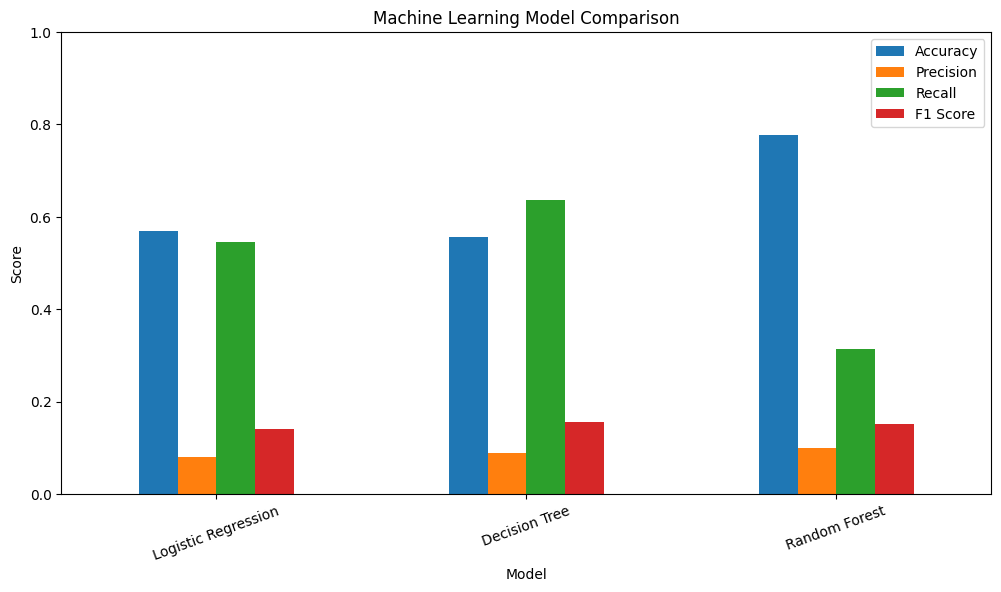

In [55]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

# **Best Model**

In [56]:
best_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Decision Tree
Accuracy           0.55602
Precision         0.088371
Recall            0.637333
F1 Score           0.15522
Name: 1, dtype: object


# **Random Forest Confusion Matrix**

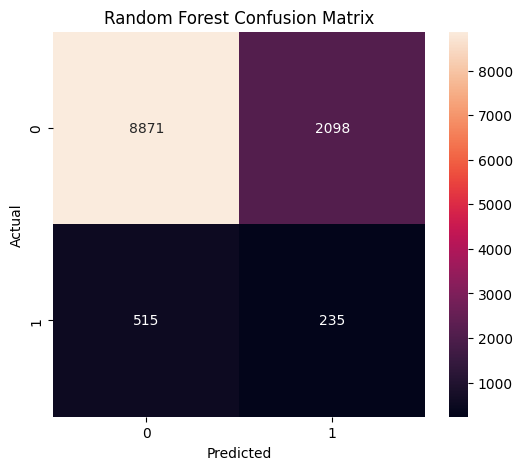

In [57]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Classification Report**

In [58]:
print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.81      0.87     10969
           1       0.10      0.31      0.15       750

    accuracy                           0.78     11719
   macro avg       0.52      0.56      0.51     11719
weighted avg       0.89      0.78      0.83     11719



# **Final Prediction Example**

In [59]:
sample_customer = X.iloc[[0]]

prediction = random_forest.predict(sample_customer)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Result: Customer is likely to make an insurance claim.")
else:
    print("Result: Customer is unlikely to make an insurance claim.")

Prediction: 0
Result: Customer is unlikely to make an insurance claim.


# **Save Model**

In [60]:
import joblib

joblib.dump(
    random_forest,
    "car_insurance_claim_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# **Download Model**

In [62]:
from google.colab import files

files.download("car_insurance_claim_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***Project Conclusion***

## Conclusion

In this project, we developed a Machine Learning model to predict whether a customer is likely to make a car insurance claim.

The dataset was analyzed using Exploratory Data Analysis and preprocessing techniques. Categorical features were encoded using One-Hot Encoding and numerical features were scaled.

Three Machine Learning algorithms were trained and compared:
1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were evaluated using Accuracy, Precision, Recall and F1 Score.

The model with the best F1 Score was selected as the final model for insurance claim prediction.